<a href="https://colab.research.google.com/github/Arif0000/Pytorch/blob/main/task_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
(cifar100_train_images, cifar100_train_labels), (cifar100_test_images, cifar100_test_labels) = keras.datasets.cifar100.load_data()

print("CIFAR-100 Training images shape:", cifar100_train_images.shape)
print("CIFAR-100 Testing images shape:", cifar100_test_images.shape)
print("CIFAR-100 Training labels shape:", cifar100_train_labels.shape)
print("CIFAR-100 Testing labels shape:", cifar100_test_labels.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
CIFAR-100 Training images shape: (50000, 32, 32, 3)
CIFAR-100 Testing images shape: (10000, 32, 32, 3)
CIFAR-100 Training labels shape: (50000, 1)
CIFAR-100 Testing labels shape: (10000, 1)


In [3]:
cifar100_train_images = cifar100_train_images.astype('float32') / 255
cifar100_test_images = cifar100_test_images.astype('float32') / 255

In [4]:
num_classes = 100

cifar100_train_labels = to_categorical(cifar100_train_labels, num_classes)
cifar100_test_labels = to_categorical(cifar100_test_labels, num_classes)

print("Encoded training labels:", cifar100_train_labels.shape)

Encoded training labels: (50000, 100)


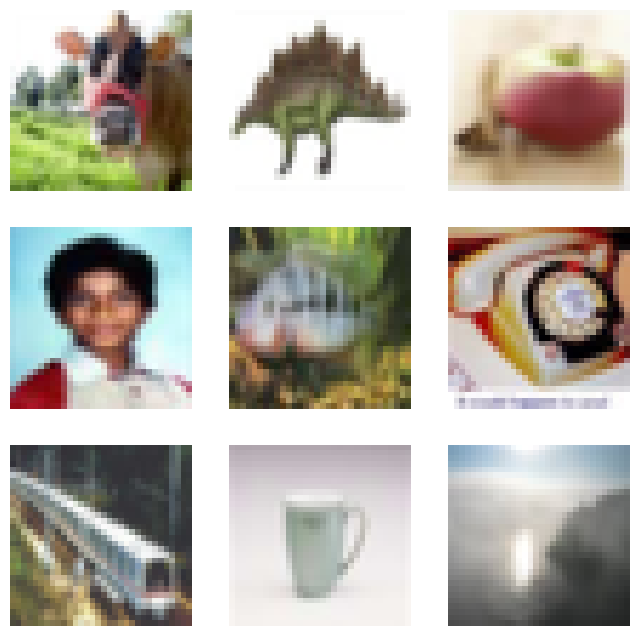

In [5]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(cifar100_train_images[i])
    plt.axis("off")

plt.show()

In [6]:
ann_model = keras.Sequential([

    layers.Flatten(input_shape=(32,32,3)),

    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(100, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,750,500 (6.68 MB)

 Trainable params: 1,750,500 (6.68 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
cnn_model = keras.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(100, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,492 (2.45 MB)

 Trainable params: 643,492 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cifar100_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

In [9]:
history_ann = ann_model.fit(
    cifar100_train_images,
    cifar100_train_labels,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.0273 - loss: 4.4749 - val_accuracy: 0.0830 - val_loss: 3.9943
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.0922 - loss: 3.9179 - val_accuracy: 0.1217 - val_loss: 3.7491
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.1327 - loss: 3.6872 - val_accuracy: 0.1437 - val_loss: 3.6495
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.1539 - loss: 3.5665 - val_accuracy: 0.1635 - val_loss: 3.5524
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.1745 - loss: 3.4662 - val_accuracy: 0.1736 - val_loss: 3.5160
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.1856 - loss: 3.3875 - val_accuracy: 0.1754 - val_loss: 3.4866
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.1970 - loss: 3.3296 - val_accuracy: 0.1833 - val_loss: 3.4382
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.2115 - loss: 3.2559 - 

In [11]:
history_cnn = cnn_model.fit(
    cifar100_train_images,
    cifar100_train_labels,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.1372 - loss: 3.6517

625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 145ms/step - accuracy: 0.1372 - loss: 3.6515 - val_accuracy: 0.2241 - val_loss: 3.2391
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.1970 - loss: 3.3054

625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 143ms/step - accuracy: 0.1970 - loss: 3.3053 - val_accuracy: 0.2681 - val_loss: 2.9682
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.2385 - loss: 3.0798

625/625 ━━━━━━━━━━━━━━━━━━━━ 89s 143ms/step - accuracy: 0.2385 - loss: 3.0797 - val_accuracy: 0.2933 - val_loss: 2.8381
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.2750 - loss: 2.8900

625/625 ━━━━━━━━━━━━━━━━━━━━ 93s 148ms/step - accuracy: 0.2750 - loss: 2.8900 - val_accuracy: 0.3254 - val_loss: 2.6920
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.3031 - loss: 2.7574

625/625 ━━━━━━━━━━━━━━━━━━━━ 154s 168ms/step - accuracy: 0.3031 - loss: 2.7575 - val_accuracy: 0.3400 - val_loss: 2.6169


In [12]:
ann_loss, ann_acc = ann_model.evaluate(cifar100_test_images, cifar100_test_labels)

print("ANN Test Accuracy:", ann_acc)
print("ANN Test Loss:", ann_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2132 - loss: 3.3325
ANN Test Accuracy: 0.2151000052690506
ANN Test Loss: 3.3378117084503174


In [13]:
cnn_loss, cnn_acc = cnn_model.evaluate(cifar100_test_images, cifar100_test_labels)

print("CNN Test Accuracy:", cnn_acc)
print("CNN Test Loss:", cnn_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.3533 - loss: 2.5807
CNN Test Accuracy: 0.35190001130104065
CNN Test Loss: 2.5913827419281006


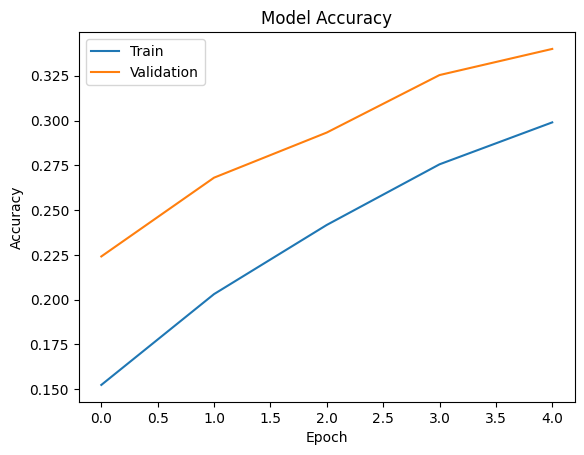

In [14]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

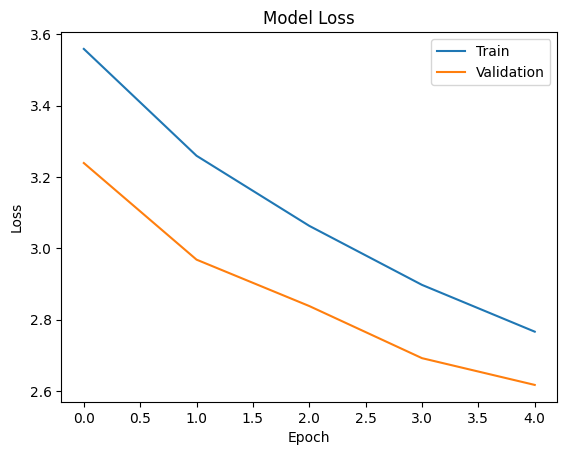

In [15]:
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step


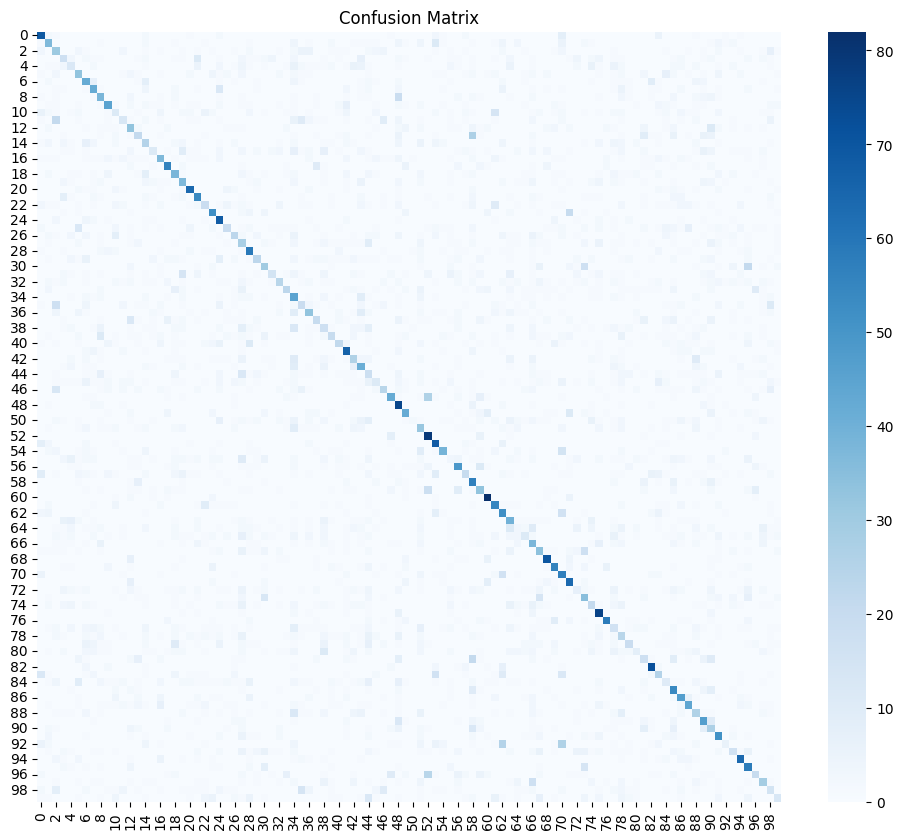

In [16]:
predictions = cnn_model.predict(cifar100_test_images)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(cifar100_test_labels, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

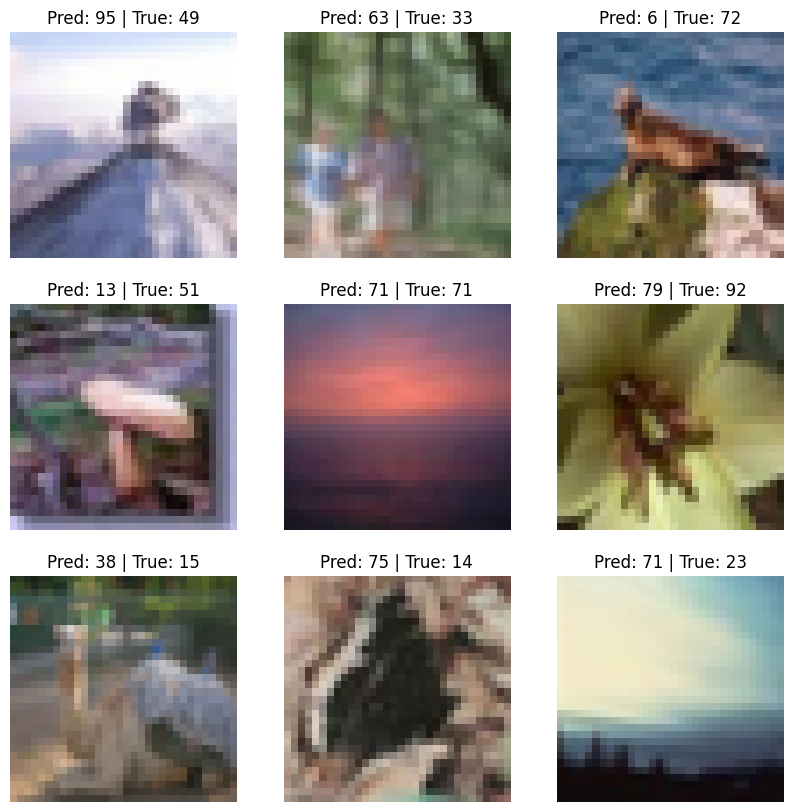

In [17]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(cifar100_test_images[i])

    predicted_label = np.argmax(predictions[i])
    true_label = np.argmax(cifar100_test_labels[i])

    plt.title(f"Pred: {predicted_label} | True: {true_label}")

    plt.axis("off")

plt.show()